# CA5: CA Groups 11
## Indra Bdr Adhikari, Zarar Zafar, and Syed Muhammad Murtaza Zaidi

## Background
The European used car market relies heavily on accurate pricing to ensure fair transactions between sellers and buyers. Factors such as vehicle age, mileage, engine specifications, fuel type, and maintenance history all influence a car’s market value.

However, pricing used cars is not straightforward. Manual valuation can be inconsistent, subjective, and dependent on individual experience. Sellers may overprice vehicles, while buyers may struggle to assess whether a car is fairly valued.

To address this, automotive companies and online marketplaces are increasingly turning to data-driven solutions to estimate car prices more accurately and consistently.

Your task is to build a machine learning model that predicts the price of a used BMW vehicle (price_usd) based on its technical specifications, usage characteristics, and market-related features.

A reliable model would help standardize pricing across markets, reduce human bias in valuation, improve transparency for buyers and sellers

You will train and evaluate models using the provided dataset and submit predictions for unseen data.

## 1. Imports

In [168]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore') # to ignore warning 

# Preprocessing
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Dimension reduction
from sklearn.decomposition import PCA

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

# Model selection & evaluation
from sklearn.model_selection import (
    train_test_split, StratifiedKFold,
    GridSearchCV, RandomizedSearchCV, cross_val_score
)
from sklearn.metrics import (
    f1_score, accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

# Global random state
RANDOM_STATE = 42

# refference: used chat to organized imported libraries


## 2. Reading data

In [169]:
# Load the test data
test = pd.read_csv("test.csv")
print(test.shape)
test.head(1)

(1000, 20)


,car_id,model,year,engine_size,horsepower,fuel_type,transmission,drivetrain,mileage_km,fuel_consumption_l_per_100km,co2_emissions_g_km,doors,seats,body_type,color,owner_count,accident_history,service_history,country_sold,ID
0,3430,X3,2024,2.7,259,diesel,automatic,RWD,0,7.0,144.0,5,5,suv,blue,0.0,no,full,Turkey,1501


In [170]:
# Load the train data
df = pd.read_csv("train.csv")
print(df.info())
df.head(2)

<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 21 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   car_id                        4000 non-null   int64  
 1   model                         4000 non-null   str    
 2   year                          4000 non-null   int64  
 3   engine_size                   3908 non-null   float64
 4   horsepower                    4000 non-null   int64  
 5   fuel_type                     4000 non-null   str    
 6   transmission                  3904 non-null   str    
 7   drivetrain                    4000 non-null   str    
 8   mileage_km                    4000 non-null   int64  
 9   fuel_consumption_l_per_100km  3889 non-null   float64
 10  co2_emissions_g_km            3922 non-null   float64
 11  price_usd                     4000 non-null   int64  
 12  doors                         4000 non-null   int64  
 13  seats         

,car_id,model,year,engine_size,horsepower,fuel_type,transmission,drivetrain,mileage_km,fuel_consumption_l_per_100km,...,price_usd,doors,seats,body_type,color,owner_count,accident_history,service_history,country_sold,ID
0,9298,1 Series,2012,2.1,184,hybrid,automatic,FWD,246543,4.6,...,9439,5,5,hatchback,black,2.0,yes,full,UK,4227
1,4697,Z4,2018,2.9,281,petrol,automatic,RWD,98238,9.4,...,54589,2,2,convertible,white,2.0,no,partial,Netherlands,4676


## 3. Data exploration and visualisation

In [171]:
print(df.isnull().sum())

car_id                            0
model                             0
year                              0
engine_size                      92
horsepower                        0
fuel_type                         0
transmission                     96
drivetrain                        0
mileage_km                        0
fuel_consumption_l_per_100km    111
co2_emissions_g_km               78
price_usd                         0
doors                             0
seats                             0
body_type                         0
color                            97
owner_count                     107
accident_history                101
service_history                  86
country_sold                      0
ID                                0
dtype: int64


In [172]:
df.describe()

,car_id,year,engine_size,horsepower,mileage_km,fuel_consumption_l_per_100km,co2_emissions_g_km,price_usd,doors,seats,owner_count,ID
count,4000.000000,4000.000000,3908.000000,4000.000000,4000.000000,3889.000000,3922.000000,4000.00000,4000.00000,4000.000000,3893.000000,4000.000000
mean,4936.066500,2016.367500,2.494959,269.998500,113302.692500,6.597994,144.697348,50585.76650,4.30525,4.725000,1.939378,2507.711000
std,2898.891051,5.444341,1.204083,80.194054,87098.910414,3.023705,67.020344,30801.00627,0.77603,0.692817,1.396635,1435.558218
min,1.000000,2005.000000,0.000000,121.000000,0.000000,0.000000,0.000000,2640.00000,2.00000,2.000000,0.000000,0.000000
25%,2417.500000,2012.000000,2.000000,212.000000,39706.500000,5.400000,118.000000,28982.25000,4.00000,5.000000,1.000000,1275.750000
50%,4890.500000,2017.000000,2.600000,260.000000,95459.000000,7.200000,158.500000,44791.00000,4.00000,5.000000,2.000000,2499.500000
75%,7446.500000,2021.000000,3.300000,319.000000,172908.750000,8.700000,191.000000,64109.25000,5.00000,5.000000,3.000000,3757.250000
max,9999.000000,2024.000000,5.000000,682.000000,300000.000000,12.800000,286.000000,213851.00000,5.00000,5.000000,5.000000,4999.000000


In [173]:
# Creating new df without irevalent columns
new_df = df.drop(columns = ['car_id', 'color'])
test_df = test.drop(columns = ['car_id', 'color'])
new_df.shape

(4000, 19)

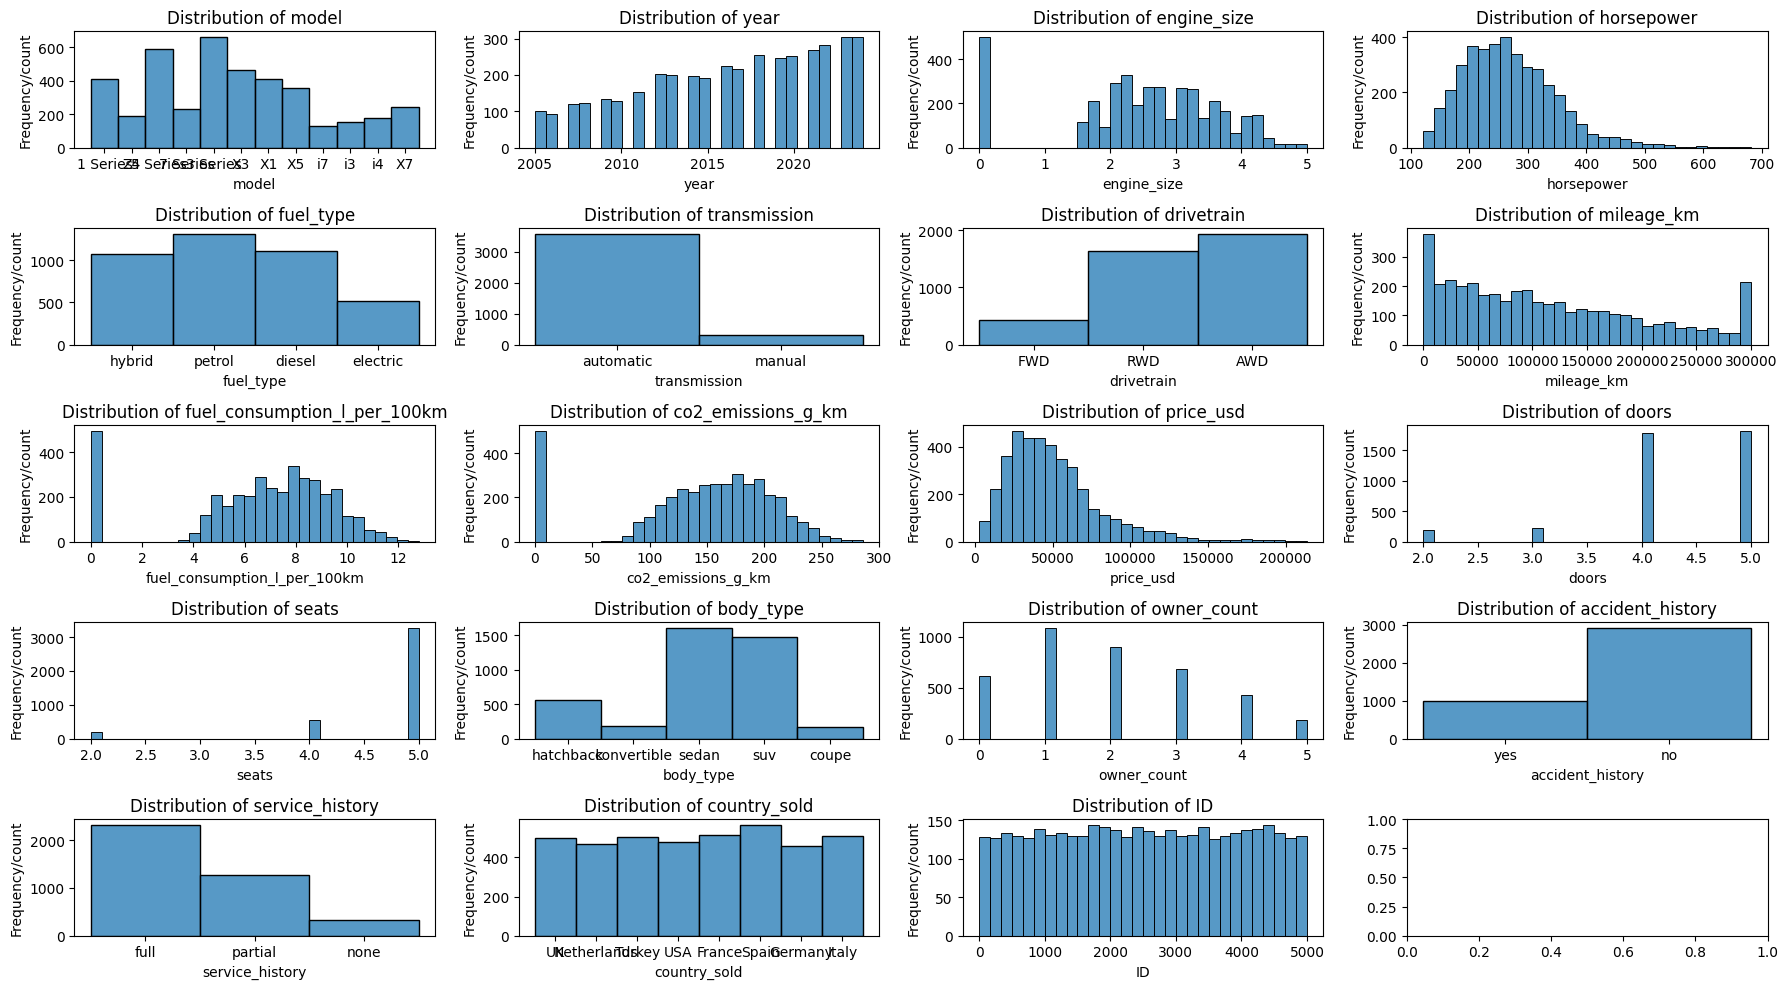

In [174]:
fig, axes = plt.subplots(5, 4, figsize=(18, 10))
axes = axes.flatten()

for i, feature in enumerate(new_df.columns):
    sns.histplot(df[feature], bins=30, ax=axes[i])
    axes[i].set_title(f'Distribution of {feature}')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Frequency/count')

plt.tight_layout()
plt.show()

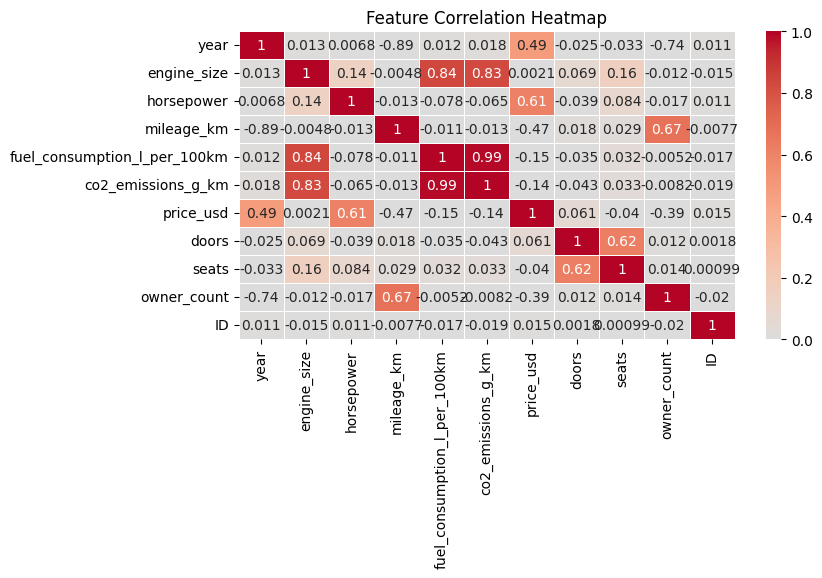

In [175]:
# Calculate the correlation matrix for numeric columns only
corr_matrix = new_df.select_dtypes(include=['number']).corr()

plt.figure(figsize=(8, 4))

# Draw the heatmap
sns.heatmap(corr_matrix, 
            annot=True,      
            cmap='coolwarm',
            vmin=0, vmax=1, 
            center=0,        # Ensure 0 is the neutral color 
            linewidths=0.5)  # Add small gaps

plt.title("Feature Correlation Heatmap")
plt.show()

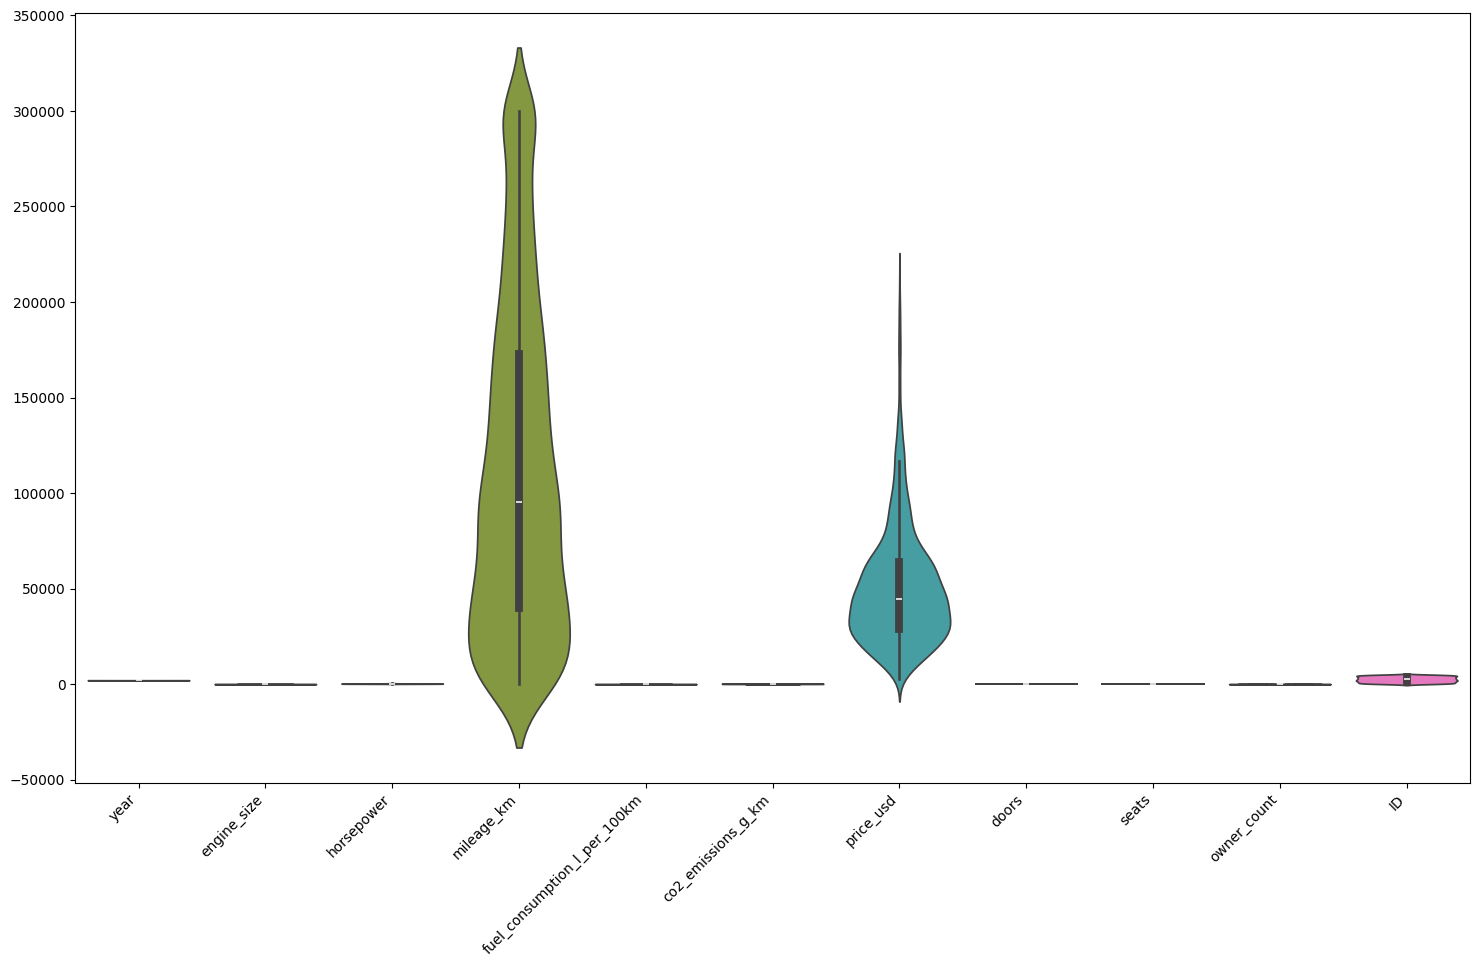

In [176]:
# Identify value ranges and potential outliers
cols=new_df.columns

fig, ax = plt.subplots(1, 1, figsize=(18, 10))  

data = pd.DataFrame(df, columns=cols)  

sns.violinplot(data=data, ax=ax)
plt.xticks(rotation=45, ha='right')
plt.show()

## 4.  Data cleaning

In [177]:
# Duplicates
print(new_df.duplicated().sum())
test_df.duplicated().sum()

0


0

In [178]:
# Duplicates without columns ID
new_df.drop(columns=["ID"]).duplicated().sum()

0

In [179]:
# Creating new df without columns ID
new_df = new_df.drop(columns=["ID"])
test_df = test_df.drop(columns=["ID"])
new_df.shape

(4000, 18)

In [180]:
print(new_df.isnull().sum())
new_df[new_df.columns].dtypes

model                             0
year                              0
engine_size                      92
horsepower                        0
fuel_type                         0
transmission                     96
drivetrain                        0
mileage_km                        0
fuel_consumption_l_per_100km    111
co2_emissions_g_km               78
price_usd                         0
doors                             0
seats                             0
body_type                         0
owner_count                     107
accident_history                101
service_history                  86
country_sold                      0
dtype: int64


model                               str
year                              int64
engine_size                     float64
horsepower                        int64
fuel_type                           str
transmission                        str
drivetrain                          str
mileage_km                        int64
fuel_consumption_l_per_100km    float64
co2_emissions_g_km              float64
price_usd                         int64
doors                             int64
seats                             int64
body_type                           str
owner_count                     float64
accident_history                    str
service_history                     str
country_sold                        str
dtype: object

In [185]:
df_clean = new_df.copy()
df_clean_test = test_df.copy()

# separate numeric and categorical columns
numeric_cols     = df_clean.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df_clean.select_dtypes(include=['object', 'category']).columns.tolist()
numeric_cols_test = df_clean_test.select_dtypes(include=np.number).columns.tolist()

print(numeric_cols)
print(categorical_cols)

# numeric columns with median
num_imputer = SimpleImputer(strategy='median')
df_clean[numeric_cols] = num_imputer.fit_transform(df_clean[numeric_cols])
df_clean_test[numeric_cols_test] = num_imputer.fit_transform(df_clean_test[numeric_cols_test])

# categorical columns with mode
cat_imputer = SimpleImputer(strategy='most_frequent')
df_clean[categorical_cols] = cat_imputer.fit_transform(df_clean[categorical_cols])
df_clean_test[categorical_cols] = cat_imputer.fit_transform(df_clean_test[categorical_cols])


df_clean.isnull().sum()

['year', 'engine_size', 'horsepower', 'mileage_km', 'fuel_consumption_l_per_100km', 'co2_emissions_g_km', 'price_usd', 'doors', 'seats', 'owner_count']
['model', 'fuel_type', 'transmission', 'drivetrain', 'body_type', 'accident_history', 'service_history', 'country_sold']


model                           0
year                            0
engine_size                     0
horsepower                      0
fuel_type                       0
transmission                    0
drivetrain                      0
mileage_km                      0
fuel_consumption_l_per_100km    0
co2_emissions_g_km              0
price_usd                       0
doors                           0
seats                           0
body_type                       0
owner_count                     0
accident_history                0
service_history                 0
country_sold                    0
dtype: int64

In [186]:
new_df.select_dtypes(include=['number']).corr()

,year,engine_size,horsepower,mileage_km,fuel_consumption_l_per_100km,co2_emissions_g_km,price_usd,doors,seats,owner_count
year,1.000000,0.013375,0.006812,-0.893766,0.012358,0.017558,0.487252,-0.024664,-0.033330,-0.742688
engine_size,0.013375,1.000000,0.135524,-0.004842,0.836269,0.829555,0.002149,0.068714,0.161790,-0.011682
horsepower,0.006812,0.135524,1.000000,-0.013179,-0.077848,-0.065126,0.614136,-0.038639,0.083928,-0.016637
mileage_km,-0.893766,-0.004842,-0.013179,1.000000,-0.011382,-0.013368,-0.468193,0.017659,0.029321,0.674395
fuel_consumption_l_per_100km,0.012358,0.836269,-0.077848,-0.011382,1.000000,0.992063,-0.147882,-0.035452,0.032095,-0.005168
co2_emissions_g_km,0.017558,0.829555,-0.065126,-0.013368,0.992063,1.000000,-0.139542,-0.043309,0.033065,-0.008160
price_usd,0.487252,0.002149,0.614136,-0.468193,-0.147882,-0.139542,1.000000,0.061370,-0.040021,-0.392778
doors,-0.024664,0.068714,-0.038639,0.017659,-0.035452,-0.043309,0.061370,1.000000,0.618021,0.011855
seats,-0.033330,0.161790,0.083928,0.029321,0.032095,0.033065,-0.040021,0.618021,1.000000,0.013979
owner_count,-0.742688,-0.011682,-0.016637,0.674395,-0.005168,-0.008160,-0.392778,0.011855,0.013979,1.000000


In [187]:
print("No. of data more than mean price:", df_clean[df_clean["price_usd"] > df_clean["price_usd"]. mean()].shape[0])
print("No. of data less than mean price:", df_clean[df_clean["price_usd"] < df_clean["price_usd"]. mean()].shape[0])

No. of data more than mean price: 1642
No. of data less than mean price: 2358


## 5. Data preprocessing

In [188]:
df_clean.columns

Index(['model', 'year', 'engine_size', 'horsepower', 'fuel_type',
       'transmission', 'drivetrain', 'mileage_km',
       'fuel_consumption_l_per_100km', 'co2_emissions_g_km', 'price_usd',
       'doors', 'seats', 'body_type', 'owner_count', 'accident_history',
       'service_history', 'country_sold'],
      dtype='str')

In [189]:
for i in categorical_cols:
    print("Column:", i)
    print("No. of uniques value:",len(df_clean[i].unique()))

Column: model
No. of uniques value: 12
Column: fuel_type
No. of uniques value: 4
Column: transmission
No. of uniques value: 2
Column: drivetrain
No. of uniques value: 3
Column: body_type
No. of uniques value: 5
Column: accident_history
No. of uniques value: 2
Column: service_history
No. of uniques value: 3
Column: country_sold
No. of uniques value: 8


In [190]:
df_clean["transmission"].unique()

<ArrowStringArray>
['automatic', 'manual']
Length: 2, dtype: str

In [191]:
df_clean["accident_history"].unique()

<ArrowStringArray>
['yes', 'no']
Length: 2, dtype: str

In [192]:
# features engineering
def data_clean(df_clean):
    df_clean['accident_history'] = df_clean['accident_history'].map({'yes': 1, 'no': 0})
    df_clean['transmission'] = df_clean['transmission'].map({'automatic': 1, 'manual': 0})

    current_year = 2026
    df_clean['car_age'] = current_year - df_clean['year']
    df_clean['hp_per_engine'] = df_clean['horsepower'] / df_clean['engine_size'] # engine efficiency
    df_clean['km_per_year'] = df_clean['mileage_km'] / (df_clean['car_age'] + 1) #mileage per year

    df_clean['service_history'] = df_clean['service_history'].map({
        'none': 0,
        'partial': 1,
        'full': 2
    })
    return df_clean

data_clean(df_clean)
data_clean(df_clean_test)

,model,year,engine_size,horsepower,fuel_type,transmission,drivetrain,mileage_km,fuel_consumption_l_per_100km,co2_emissions_g_km,doors,seats,body_type,owner_count,accident_history,service_history,country_sold,car_age,hp_per_engine,km_per_year
0,X3,2024.0,2.7,259.0,diesel,1,RWD,0.0,7.0,144.0,5.0,5.0,suv,0.0,0,2,Turkey,2.0,95.925926,0.000000
1,3 Series,2011.0,2.7,199.0,diesel,1,RWD,177234.0,7.3,169.0,4.0,5.0,sedan,2.0,0,2,Germany,15.0,73.703704,11077.125000
2,3 Series,2024.0,2.1,214.0,diesel,1,AWD,0.0,6.6,134.0,4.0,5.0,sedan,2.0,0,2,Netherlands,2.0,101.904762,0.000000
3,3 Series,2015.0,1.9,224.0,petrol,1,AWD,83861.0,7.9,169.0,4.0,5.0,sedan,1.0,1,1,Italy,11.0,117.894737,6988.416667
4,3 Series,2009.0,2.5,263.0,diesel,0,RWD,189526.0,7.1,152.0,4.0,5.0,sedan,4.0,1,2,Turkey,17.0,105.200000,10529.222222
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,5 Series,2019.0,3.2,319.0,petrol,1,RWD,59067.0,10.1,235.0,4.0,5.0,sedan,3.0,0,2,Turkey,7.0,99.687500,7383.375000
996,i7,2008.0,0.0,551.0,electric,1,RWD,106002.0,0.0,0.0,4.0,4.0,sedan,2.0,0,1,Spain,18.0,inf,5579.052632
997,i7,2022.0,0.0,512.0,electric,1,AWD,18441.0,0.0,0.0,4.0,4.0,sedan,2.0,1,2,USA,4.0,inf,3688.200000
998,3 Series,2018.0,2.1,181.0,hybrid,1,RWD,61917.0,4.8,107.0,4.0,5.0,sedan,2.0,0,1,Italy,8.0,86.190476,6879.666667


In [193]:
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 21 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   model                         4000 non-null   str    
 1   year                          4000 non-null   float64
 2   engine_size                   4000 non-null   float64
 3   horsepower                    4000 non-null   float64
 4   fuel_type                     4000 non-null   str    
 5   transmission                  4000 non-null   int64  
 6   drivetrain                    4000 non-null   str    
 7   mileage_km                    4000 non-null   float64
 8   fuel_consumption_l_per_100km  4000 non-null   float64
 9   co2_emissions_g_km            4000 non-null   float64
 10  price_usd                     4000 non-null   float64
 11  doors                         4000 non-null   float64
 12  seats                         4000 non-null   float64
 13  body_type     

In [194]:
df_clean.select_dtypes(include=['number']).corr()

,year,engine_size,horsepower,transmission,mileage_km,fuel_consumption_l_per_100km,co2_emissions_g_km,price_usd,doors,seats,owner_count,accident_history,service_history,car_age,hp_per_engine,km_per_year
year,1.000000,0.013134,0.006812,0.168556,-0.893766,0.011525,0.016925,0.487252,-0.024664,-0.033330,-0.733076,-0.327108,0.288455,-1.000000,-0.003987,-0.620804
engine_size,0.013134,1.000000,0.134021,0.012941,-0.004777,0.813547,0.811599,0.001908,0.067629,0.159843,-0.011515,0.019827,-0.002208,-0.013134,-0.394488,-0.004125
horsepower,0.006812,0.134021,1.000000,0.137873,-0.013179,-0.078044,-0.064177,0.614136,-0.038639,0.083928,-0.016447,0.002065,0.001921,-0.006812,0.156309,-0.011354
transmission,0.168556,0.012941,0.137873,1.000000,-0.150000,-0.041650,-0.043967,0.262915,0.194220,0.064769,-0.138696,-0.074026,0.049009,-0.168556,-0.061850,-0.101050
mileage_km,-0.893766,-0.004777,-0.013179,-0.150000,1.000000,-0.010585,-0.012591,-0.468193,0.017659,0.029321,0.665753,0.301526,-0.262474,0.893766,-0.002211,0.844845
fuel_consumption_l_per_100km,0.011525,0.813547,-0.078044,-0.041650,-0.010585,1.000000,0.966611,-0.147432,-0.035166,0.031552,-0.004985,0.037540,-0.008175,-0.011525,-0.150102,-0.023862
co2_emissions_g_km,0.016925,0.811599,-0.064177,-0.043967,-0.012591,0.966611,1.000000,-0.138342,-0.043365,0.032245,-0.007708,0.030308,-0.005336,-0.016925,-0.150203,-0.020969
price_usd,0.487252,0.001908,0.614136,0.262915,-0.468193,-0.147432,-0.138342,1.000000,0.061370,-0.040021,-0.388359,-0.228006,0.212095,-0.487252,-0.146319,-0.360880
doors,-0.024664,0.067629,-0.038639,0.194220,0.017659,-0.035166,-0.043365,0.061370,1.000000,0.618021,0.011469,0.008758,-0.005066,0.024664,-0.050136,0.011541
seats,-0.033330,0.159843,0.083928,0.064769,0.029321,0.031552,0.032245,-0.040021,0.618021,1.000000,0.013648,-0.004667,-0.007942,0.033330,-0.042592,0.020224


In [195]:
# clean to remove inf values
df_clean['hp_per_engine'] = df_clean['hp_per_engine'].replace([np.inf, -np.inf], np.nan)
df_clean['hp_per_engine'] = df_clean['hp_per_engine'].fillna(df_clean['hp_per_engine'].median())

df_clean_test['hp_per_engine'] = df_clean_test['hp_per_engine'].replace([np.inf, -np.inf], np.nan)
df_clean_test['hp_per_engine'] = df_clean_test['hp_per_engine'].fillna(df_clean_test['hp_per_engine'].median())

Feature ranking (descending importance):
 1) 0.1173 horsepower
 2) 0.1116 km_per_year
 3) 0.1075 mileage_km
 4) 0.1029 hp_per_engine
 5) 0.0958 co2_emissions_g_km
 6) 0.0911 fuel_consumption_l_per_100km
 7) 0.0831 engine_size
 8) 0.0611 car_age
 9) 0.0609 year
10) 0.0516 owner_count
11) 0.0355 service_history
12) 0.0338 doors
13) 0.0214 accident_history
14) 0.0175 seats
15) 0.0087 transmission


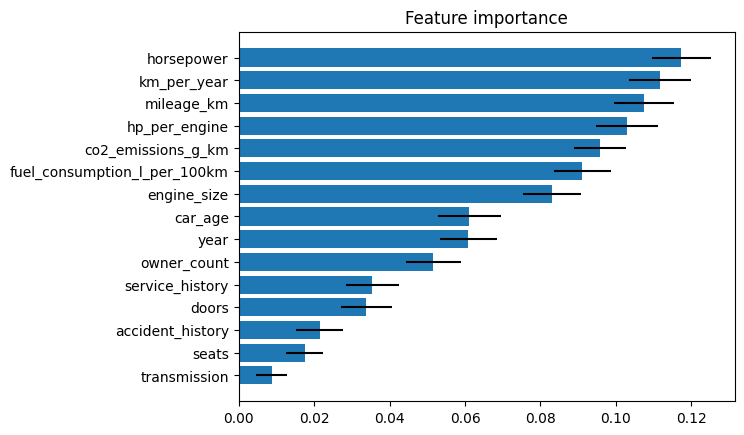

In [196]:
# Source; from lecture 12, to use the random forrest for features selection.
# Checking for missing values in the feature matrix and target
target = "price_usd"
new_features = df_clean.select_dtypes(include=['number']).columns.drop(target)

X = df_clean[new_features]
y = df_clean[target]

# Split the data into a training and test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train a random forest classifier
clf = RandomForestClassifier(n_estimators=500, random_state=42)
clf.fit(X_train, y_train)

# Print the feature ranking as a list
print("Feature ranking (descending importance):")
ranking = { new_features[i]: clf.feature_importances_[i] for i in range(X.shape[1]) }
feature_name_max_length = max(ranking.keys(), key=len)
for i, feature in enumerate(sorted(ranking, key=ranking.get, reverse=True)):
    print(f"{i+1:2d}) {ranking[feature]:.4f} {feature}")

# Plot the feature importances of the forest
# Feature names on the y-axis, importances on the x-axis
# The most important features are at the top
# This means we first have to sort the features
feature_importance = clf.feature_importances_
indices = np.argsort(feature_importance)

plt.figure()
plt.title("Feature importance")
plt.yticks(range(X.shape[1]), np.array(new_features)[indices])

# Add error bars as well by computing the standard deviation of the feature importances
std = np.std([tree.feature_importances_ for tree in clf.estimators_], axis=0)
plt.barh(range(X.shape[1]), feature_importance[indices], xerr=std[indices], align="center")

plt.show()

In [197]:
df_clean = df_clean.drop(columns=['transmission', 'seats', 'accident_history','doors', 'service_history'])
df_clean_test = df_clean_test.drop(columns=['transmission', 'seats', 'accident_history','doors', 'service_history'])

## 6. Preprocessing Setup

In [198]:
df_clean.columns

Index(['model', 'year', 'engine_size', 'horsepower', 'fuel_type', 'drivetrain',
       'mileage_km', 'fuel_consumption_l_per_100km', 'co2_emissions_g_km',
       'price_usd', 'body_type', 'owner_count', 'country_sold', 'car_age',
       'hp_per_engine', 'km_per_year'],
      dtype='str')

In [202]:
TARGET = 'price_usd'
X = df_clean.drop(columns=[TARGET])
y = df_clean[TARGET]

# identify column types
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
numeric_cols     = X.select_dtypes(include=np.number).columns.tolist()

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),  # fill missing with median
    ('scaler',  StandardScaler())                   # scale the numbers
])
 
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),  # fill missing with mode
    ('ohe',     OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer,     numeric_cols),
    ('cat', categorical_transformer, categorical_cols)
])

# 60 to 40 split 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.40, random_state=RANDOM_STATE
)
print(f'\nTrain: {X_train.shape}, Test: {X_test.shape}')


Train: (2400, 15), Test: (1600, 15)


## 7. Cross-Validation Helper

In [203]:
def cv_report(pipeline, X, y, label):
    scores = cross_val_score(pipeline, X, y, cv=cv, scoring=SCORING, n_jobs=-1)
    
    # convert to positive MAE
    mae_scores = -scores
    
    print(f'{label:<45} MAE: {mae_scores.mean():.4f} ± {mae_scores.std():.4f}')
    return mae_scores.mean()

## 8. Pipelines

In [204]:
from sklearn.linear_model import Ridge

pipe_reg_a = Pipeline([
    ('prep', preprocessor),
    ('model', Ridge())
])

In [205]:
param_grid = {
    'model__alpha': [0.01, 0.1, 1, 10, 100]
}

from sklearn.model_selection import KFold

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

grid_reg_a = GridSearchCV(
    pipe_reg_a,
    param_grid,
    cv=cv,
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)

In [206]:
grid_reg_a.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...l', Ridge())])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__alpha': [0.01, 0.1, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_absolute_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the sc

In [211]:
from sklearn.metrics import mean_absolute_error

best_model_a = grid_reg_a.best_estimator_

y_pred = best_model_a.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)

print("Best alpha:", grid_reg_a.best_params_)
print("Test MAE:", mae)

Best alpha: {'model__alpha': 0.1}
Test MAE: 5631.273822106875


In [212]:
from sklearn.model_selection import cross_val_score
import numpy as np

scores = cross_val_score(
    best_model_a,
    X_train,
    y_train,
    cv=cv,
    scoring='neg_mean_absolute_error'
)

mae_scores = -scores

print(f"CV MAE: {mae_scores.mean():.4f} ± {mae_scores.std():.4f}")

CV MAE: 5570.7963 ± 222.2884


### G B

In [213]:
from sklearn.ensemble import GradientBoostingRegressor

pipe_gb = Pipeline([
    ('prep', preprocessor),
    ('model', GradientBoostingRegressor(random_state=RANDOM_STATE))
])

In [214]:
param_grid = {
    'model__n_estimators': [100, 200],
    'model__learning_rate': [0.05, 0.1],
    'model__max_depth': [2, 3, 4],
    'model__subsample': [0.8, 1.0]
}

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)


grid_gb = GridSearchCV(
    pipe_gb,
    param_grid,
    cv=cv,
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)

grid_gb.fit(X_train, y_train)


best_gb = grid_gb.best_estimator_

y_pred = best_gb.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)

print("Best params:", grid_gb.best_params_)
print("Test MAE:", mae)

Best params: {'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 200, 'model__subsample': 0.8}
Test MAE: 4197.225791632555


## Submission

In [216]:
print(X.columns)
df_clean_test.columns

Index(['model', 'year', 'engine_size', 'horsepower', 'fuel_type', 'drivetrain',
       'mileage_km', 'fuel_consumption_l_per_100km', 'co2_emissions_g_km',
       'body_type', 'owner_count', 'country_sold', 'car_age', 'hp_per_engine',
       'km_per_year'],
      dtype='str')


Index(['model', 'year', 'engine_size', 'horsepower', 'fuel_type', 'drivetrain',
       'mileage_km', 'fuel_consumption_l_per_100km', 'co2_emissions_g_km',
       'body_type', 'owner_count', 'country_sold', 'car_age', 'hp_per_engine',
       'km_per_year'],
      dtype='str')

In [215]:
df_clean_test.head()

,model,year,engine_size,horsepower,fuel_type,drivetrain,mileage_km,fuel_consumption_l_per_100km,co2_emissions_g_km,body_type,owner_count,country_sold,car_age,hp_per_engine,km_per_year
0,X3,2024.0,2.7,259.0,diesel,RWD,0.0,7.0,144.0,suv,0.0,Turkey,2.0,95.925926,0.000000
1,3 Series,2011.0,2.7,199.0,diesel,RWD,177234.0,7.3,169.0,sedan,2.0,Germany,15.0,73.703704,11077.125000
2,3 Series,2024.0,2.1,214.0,diesel,AWD,0.0,6.6,134.0,sedan,2.0,Netherlands,2.0,101.904762,0.000000
3,3 Series,2015.0,1.9,224.0,petrol,AWD,83861.0,7.9,169.0,sedan,1.0,Italy,11.0,117.894737,6988.416667
4,3 Series,2009.0,2.5,263.0,diesel,RWD,189526.0,7.1,152.0,sedan,4.0,Turkey,17.0,105.200000,10529.222222


In [218]:
test_df.head()

,model,year,engine_size,horsepower,fuel_type,transmission,drivetrain,mileage_km,fuel_consumption_l_per_100km,co2_emissions_g_km,doors,seats,body_type,owner_count,accident_history,service_history,country_sold
0,X3,2024,2.7,259,diesel,automatic,RWD,0,7.0,144.0,5,5,suv,0.0,no,full,Turkey
1,3 Series,2011,2.7,199,diesel,automatic,RWD,177234,7.3,169.0,4,5,sedan,NaN,no,full,Germany
2,3 Series,2024,2.1,214,diesel,automatic,AWD,0,6.6,134.0,4,5,sedan,NaN,no,full,Netherlands
3,3 Series,2015,1.9,224,petrol,automatic,AWD,83861,7.9,169.0,4,5,sedan,1.0,yes,partial,Italy
4,3 Series,2009,2.5,263,diesel,manual,RWD,189526,7.1,152.0,4,5,sedan,4.0,yes,full,Turkey


In [219]:
X_test_final = df_clean_test

test_ids = test['ID']

best_model = grid_gb.best_estimator_

predictions = best_model.predict(X_test_final)

submission = pd.DataFrame({
    'ID': test_ids,
    'price_usd': predictions
})

submission.to_csv('submission.csv', index=False)
